In [ ]:
import pandas as pd

df = pd.read_csv("sales_data.csv")

print("EDA Project by Karthik")
print("Total rows:", len(df))

df.head()

,order_id,product,category,price,quantity,revenue,region,payment_method
0,1001,Fiction Book,Home & Kitchen,1874.27,9,16868.43,South,Debit Card
1,1002,Mixer,Electronics,1649.20,9,14842.80,East,Cash on Delivery
2,1003,Textbook,Sports,2836.59,4,11346.36,North,Cash on Delivery
3,1004,Textbook,Home & Kitchen,4315.10,5,21575.50,North,Cash on Delivery
4,1005,Textbook,Home & Kitchen,2567.55,2,5135.10,East,Cash on Delivery


In [ ]:
print("Shape:", df.shape)
print("\nData Types:\n", df.dtypes)
print("\nNull Values:\n", df.isnull().sum())
print("\nDescribe:\n", df.describe())

Shape: (50, 8)

Data Types:
 order_id            int64
product            object
category           object
price             float64
quantity            int64
revenue           float64
region             object
payment_method     object
dtype: object

Null Values:
 order_id          0
product           0
category          0
price             0
quantity          0
revenue           0
region            0
payment_method    0
dtype: int64

Describe:
          order_id        price   quantity      revenue
count    50.00000    50.000000  50.000000     50.00000
mean   1025.50000  2502.892200   5.840000  15458.19640
std      14.57738  1304.801068   3.092849  12799.69529
min    1001.00000   341.810000   1.000000    359.21000
25%    1013.25000  1632.227500   3.000000   4574.19500
50%    1025.50000  2373.485000   6.000000  13484.32500
75%    1037.75000  3285.282500   9.000000  21910.74250
max    1050.00000  4960.900000  10.000000  44648.10000


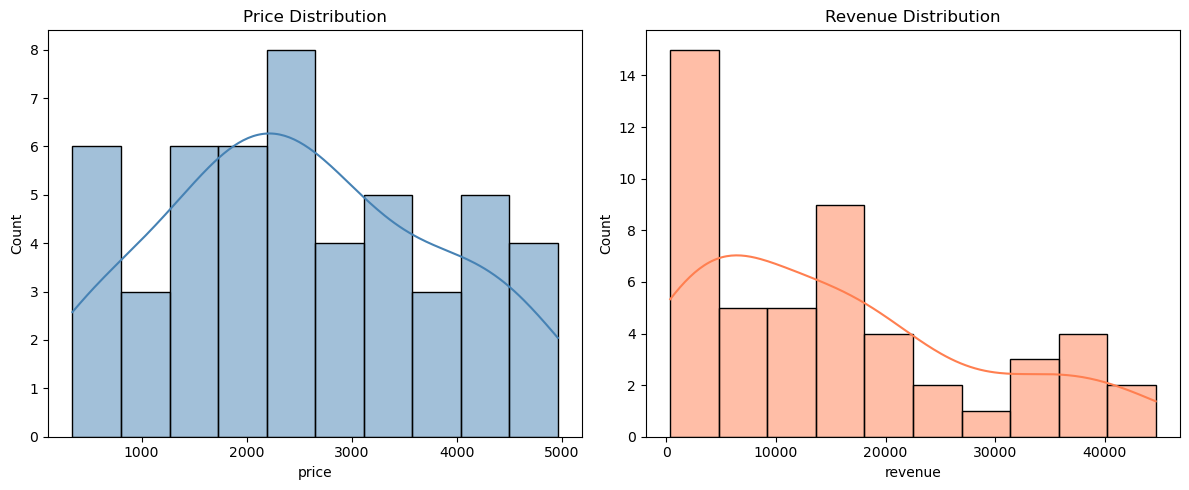

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import os

os.makedirs('outputs/plots', exist_ok=True)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.histplot(df['price'], bins=10, kde=True, color='steelblue', ax=axes[0])
axes[0].set_title('Price Distribution')

sns.histplot(df['revenue'], bins=10, kde=True, color='coral', ax=axes[1])
axes[1].set_title('Revenue Distribution')

plt.tight_layout()
plt.savefig('outputs/plots/histogram_price_revenue.png', dpi=150, bbox_inches='tight')
plt.show()

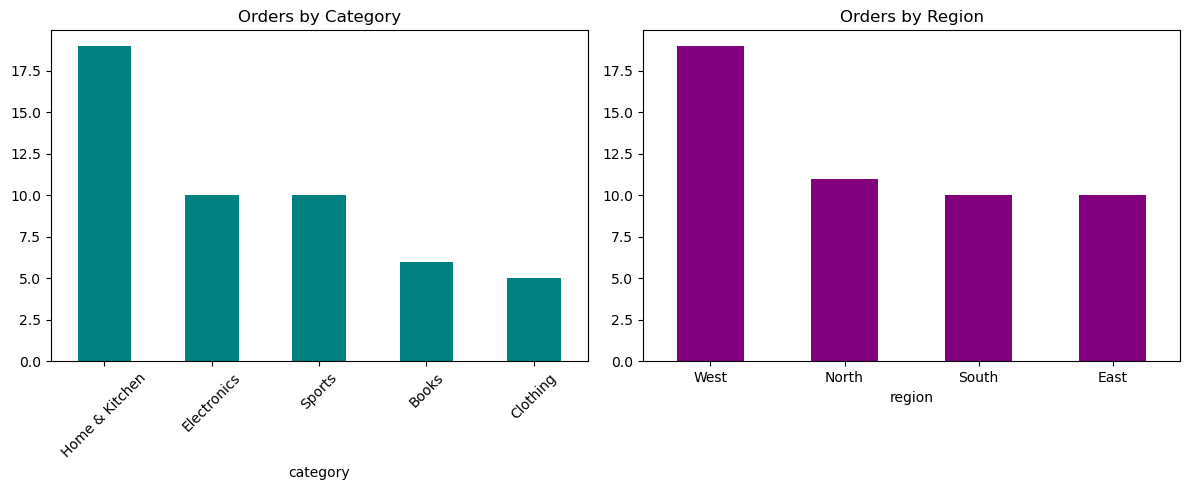

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import os

os.makedirs('outputs/plots', exist_ok=True)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

df['category'].value_counts().plot(kind='bar', color='teal', ax=axes[0])
axes[0].set_title('Orders by Category')
axes[0].tick_params(axis='x', rotation=45)

df['region'].value_counts().plot(kind='bar', color='purple', ax=axes[1])
axes[1].set_title('Orders by Region')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.savefig('outputs/plots/barplot_category_region.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
import sqlite3

conn = sqlite3.connect(':memory:')
df.to_sql('orders', conn, index=False, if_exists='replace')
print("Database ready ✅")

Database ready ✅


In [ ]:
q1 = pd.read_sql_query("""
    SELECT product, ROUND(SUM(revenue),2) AS total_revenue
    FROM orders
    GROUP BY product
    ORDER BY total_revenue DESC
    LIMIT 5
""", conn)
print("Q1: Top 5 Products by Revenue")
print(q1.to_string(index=False))

Q1: Top 5 Products by Revenue
 product  total_revenue
    Lamp      182996.82
Textbook      116392.15
   Saree      115587.92
   Phone      111101.99
   Jeans       74309.51


In [ ]:
q2 = pd.read_sql_query("""
    SELECT category, ROUND(SUM(revenue),2) AS total_revenue
    FROM orders
    GROUP BY category
    ORDER BY total_revenue DESC
""", conn)
print("Q2: Revenue by Category")
print(q2.to_string(index=False))

Q2: Revenue by Category
      category  total_revenue
Home & Kitchen      286720.27
   Electronics      166629.17
        Sports      161055.39
      Clothing      116888.22
         Books       41616.77


In [ ]:
q3 = pd.read_sql_query("""
    SELECT region, COUNT(order_id) AS total_orders
    FROM orders
    GROUP BY region
    ORDER BY total_orders DESC
""", conn)
print("Q3: Region-wise Order Count")
print(q3.to_string(index=False))

Q3: Region-wise Order Count
region  total_orders
  West            19
 North            11
 South            10
  East            10


In [ ]:
q4 = pd.read_sql_query("""
    SELECT category, ROUND(AVG(revenue),2) AS avg_order_value
    FROM orders
    GROUP BY category
    ORDER BY avg_order_value DESC
""", conn)
print("Q4: Average Order Value by Category")
print(q4.to_string(index=False))

Q4: Average Order Value by Category
      category  avg_order_value
      Clothing         23377.64
   Electronics         16662.92
        Sports         16105.54
Home & Kitchen         15090.54
         Books          6936.13


In [ ]:
q6 = pd.read_sql_query("""
    SELECT payment_method, COUNT(order_id) AS total_orders
    FROM orders
    GROUP BY payment_method
    ORDER BY total_orders DESC
""", conn)
print("Q6: Payment Method wise Order Count")
print(q6.to_string(index=False))

Q6: Payment Method wise Order Count
  payment_method  total_orders
      NetBanking            15
Cash on Delivery            13
     Credit Card             9
      Debit Card             7
             UPI             6


In [ ]:
q7 = pd.read_sql_query("""
    SELECT category, ROUND(AVG(price),2) AS avg_price
    FROM orders
    GROUP BY category
    ORDER BY avg_price DESC
""", conn)
print("Q7: Average Price by Category")
print(q7.to_string(index=False))

Q7: Average Price by Category
      category  avg_price
      Clothing    3134.07
Home & Kitchen    2558.49
        Sports    2542.96
   Electronics    2504.12
         Books    1732.00


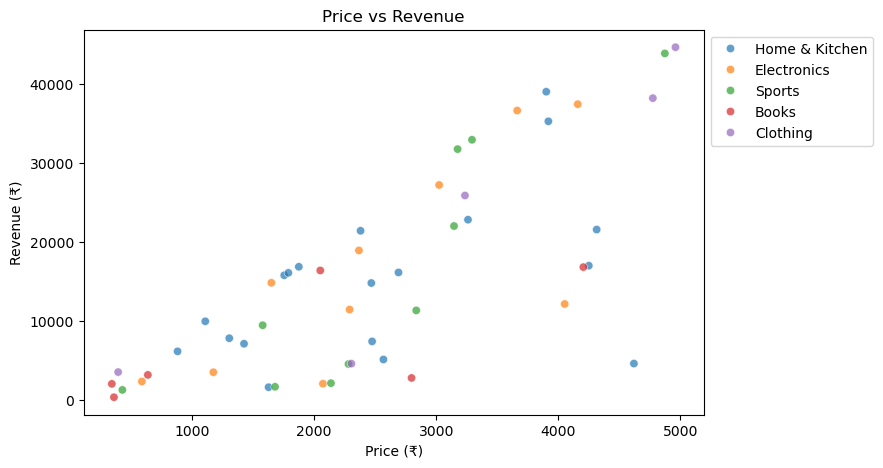

In [ ]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x='price', y='revenue', hue='category', alpha=0.7)
plt.title('Price vs Revenue')
plt.xlabel('Price (₹)')
plt.ylabel('Revenue (₹)')
plt.legend(bbox_to_anchor=(1,1))
plt.savefig('outputs/plots/scatter_price_revenue.png', dpi=150, bbox_inches='tight')
plt.show()

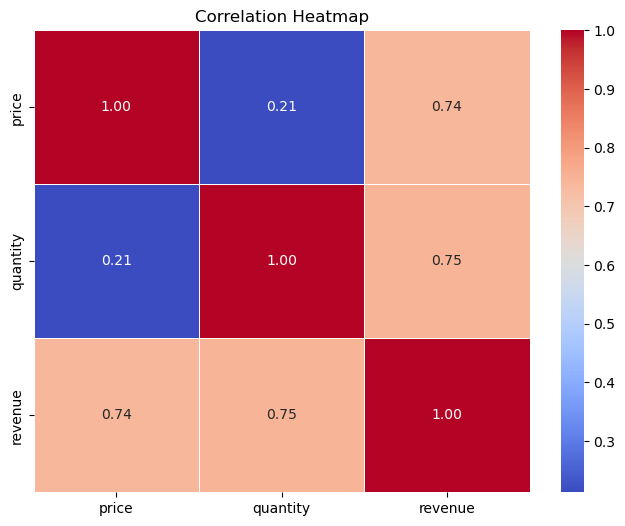

In [ ]:
plt.figure(figsize=(8,6))
corr = df[['price','quantity','revenue']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap')
plt.savefig('outputs/plots/heatmap_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

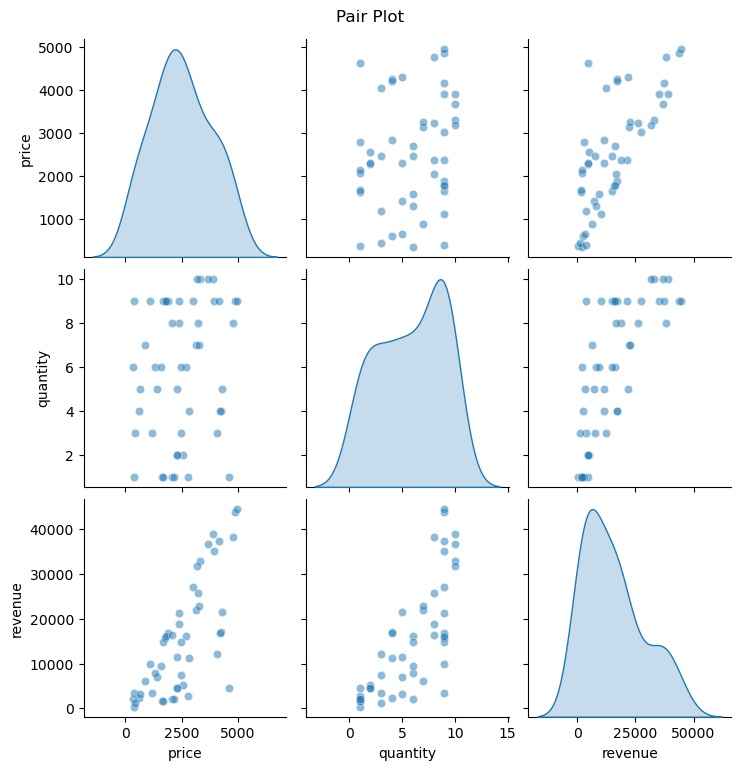

In [ ]:
sns.pairplot(df[['price','quantity','revenue']], diag_kind='kde', plot_kws={'alpha':0.5})
plt.suptitle('Pair Plot', y=1.02)
plt.savefig('outputs/plots/pairplot.png', dpi=150, bbox_inches='tight')
plt.show()